In [1]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

dataset = torchvision.datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

loader = torch.utils.data.DataLoader(dataset, batch_size=64, shuffle=True)

100%|██████████| 170M/170M [00:06<00:00, 27.1MB/s]


In [3]:
class AutoEncoder(nn.Module):

    def __init__(self):
        super(AutoEncoder, self).__init__()

        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, 4, 2, 1),
            nn.ReLU(),

            nn.Conv2d(32, 64, 4, 2, 1),
            nn.ReLU()
        )

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(64, 32, 4, 2, 1),
            nn.ReLU(),

            nn.ConvTranspose2d(32, 3, 4, 2, 1),
            nn.Tanh()
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

In [4]:
model = AutoEncoder()

criterion = nn.L1Loss()     # or nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [5]:
epochs = 5

for epoch in range(epochs):
    for images, _ in loader:

        outputs = model(images)

        loss = criterion(outputs, images)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print("Epoch:", epoch, "Loss:", loss.item())

Epoch: 0 Loss: 0.041595473885536194
Epoch: 1 Loss: 0.03367749974131584
Epoch: 2 Loss: 0.032256972044706345
Epoch: 3 Loss: 0.02863750420510769
Epoch: 4 Loss: 0.022417372092604637


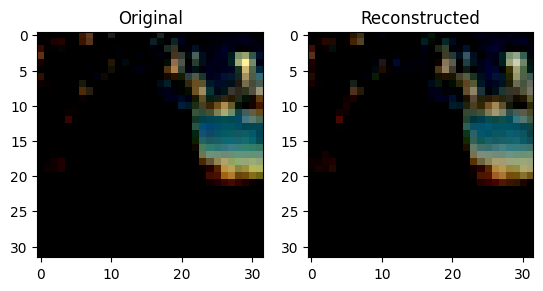

In [6]:
images, _ = next(iter(loader))
outputs = model(images)

plt.subplot(1,2,1)
plt.title("Original")
plt.imshow(images[0].permute(1,2,0).detach())

plt.subplot(1,2,2)
plt.title("Reconstructed")
plt.imshow(outputs[0].permute(1,2,0).detach())

plt.show()